In [1]:
import subprocess, sys
def run(cmd):
    print(f">> {cmd}")
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.stdout: print(result.stdout[-3000:])
    if result.stderr: print(result.stderr[-1000:])
    return result.returncode

# Install PyTorch with CUDA 12.8 (Blackwell support)
rc = run(f"{sys.executable} -m pip install torch==2.9.1 torchvision==0.24.1 torchaudio==2.9.1 "
         "--index-url https://download.pytorch.org/whl/cu128 --quiet")
if rc != 0:
    print("\n⚠ cu128 install failed — trying cu129 fallback...")
    run(f"{sys.executable} -m pip install torch==2.9.1 torchvision==0.24.1 torchaudio==2.9.1 "
        "--index-url https://download.pytorch.org/whl/cu129 --quiet")

# Other dependencies
run(f"{sys.executable} -m pip install wfdb scipy scikit-learn matplotlib numpy onnx onnxscript --quiet")
run("apt-get update")
run("apt-get install -y build-essential")
print("\n✓ Installation complete — restart kernel now.")

>> d:\anaconda3\python.exe -m pip install torch==2.9.1 torchvision==0.24.1 torchaudio==2.9.1 --index-url https://download.pytorch.org/whl/cu128 --quiet
>> d:\anaconda3\python.exe -m pip install wfdb scipy scikit-learn matplotlib numpy onnx onnxscript --quiet
>> apt-get update
'apt-get' is not recognized as an internal or external command,
operable program or batch file.

>> apt-get install -y build-essential
'apt-get' is not recognized as an internal or external command,
operable program or batch file.


✓ Installation complete — restart kernel now.


In [2]:
import os, math, time, copy, gc, warnings
from pathlib import Path
import numpy as np
import wfdb
from scipy import signal as scipy_signal
from scipy.sparse.linalg import svds
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.cuda.amp import GradScaler, autocast
warnings.filterwarnings('ignore')

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    device = torch.device('cuda')
    props = torch.cuda.get_device_properties(0)
    print(f"GPU             : {props.name}")
    print(f"Compute Cap.    : sm_{props.major}{props.minor}")
    print(f"VRAM            : {props.total_memory / 1e9:.1f} GB")
    USE_AMP = True
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device('cpu')
    USE_AMP = False
    print("⚠ No CUDA GPU found — running on CPU")
print(f"Device          : {device}")
print(f"Mixed Precision : {USE_AMP}")

PyTorch version : 2.9.1+cu128
CUDA available  : True
GPU             : NVIDIA GeForce RTX 2050
Compute Cap.    : sm_86
VRAM            : 4.3 GB
Device          : cuda
Mixed Precision : True


In [3]:
class PTBVCGLoader:
    def __init__(self, vcg_lead_indices=[12,13,14]):
        self.vcg_lead_indices = vcg_lead_indices
    def load_vcg_from_record(self, record_path):
        try:
            record = wfdb.rdrecord(record_path)
            if record.p_signal.shape[1] < 15: return None
            vcg = record.p_signal[:, self.vcg_lead_indices]
            if np.isnan(vcg).any() or np.abs(vcg).max() == 0: return None
            return vcg
        except: return None
    def load_all_vcg_from_database(self, data_dir, output_dir, max_records=None):
        Path(output_dir).mkdir(parents=True, exist_ok=True)
        data_path = Path(data_dir)
        patient_dirs = sorted([d for d in data_path.iterdir() if d.is_dir() and d.name.startswith('patient')])
        print(f"Found {len(patient_dirs)} patient directories")
        vcg_files, count = [], 0
        for pdir in patient_dirs:
            for hea in sorted(pdir.glob('*.hea')):
                if max_records and count >= max_records: break
                rec = str(hea).replace('.hea','')
                vcg = self.load_vcg_from_record(rec)
                if vcg is not None:
                    out = f"{output_dir}/vcg_{pdir.name}_{hea.stem}.npy"
                    np.save(out, vcg)
                    vcg_files.append(out)
                    count += 1
                if count % 50 == 0: print(f"  Progress: {count} records")
            if max_records and count >= max_records: break
        print(f"\n✓ Processed {count} records → {output_dir}")
        return vcg_files



In [4]:
class VCGPreprocessor:
    def __init__(self, cutoff_freq=40, fs=1000, order=4):
        self.mean = self.std = None
        nyq = 0.5 * fs
        self.b, self.a = scipy_signal.butter(order, cutoff_freq/nyq, btype='low')
    def butterworth_filter(self, data):
        out = np.zeros_like(data)
        for i in range(data.shape[1]):
            out[:,i] = scipy_signal.filtfilt(self.b, self.a, data[:,i])
        return out
    def fit_normalisation(self, sample_signals):
        """Fit mean/std on a list of 2D arrays (T,3)"""
        concat = np.concatenate(sample_signals, axis=0)
        self.mean = concat.mean(axis=0, keepdims=True)
        self.std  = concat.std(axis=0, keepdims=True) + 1e-8
    def normalize(self, data):
        return (data - self.mean) / self.std
    def preprocess(self, data, fit=False):
        """Apply filter + normalisation. If fit=True, compute stats from this single record (legacy)."""
        filtered = self.butterworth_filter(data)
        return self.normalize(filtered)



In [5]:
PATCH_SIZE = 1000
WINDOW_SIZE = 10000
PATCHES_PER_WINDOW = WINDOW_SIZE // PATCH_SIZE

class VCGDataGenerator:
    """
    Generates random 10s windows -> splits into 10 patches of 1s.
    Each call to `train_generator` yields (patches, patches) of shape
    (batch_size * 10, 1000, 3).
    """
    def __init__(self, batch_size=128, test_records=5):
        self.batch_size = batch_size
        self.test_records = test_records

    def prepare_dataset(self, vcg_files, preprocessor):
        """Load all records, preprocess, keep test records aside."""
        print("\nLoading and preprocessing records...")
        all_records = []
        for i, f in enumerate(vcg_files):
            if i % 50 == 0: print(f"{i+1}/{len(vcg_files)}")
            signal = np.load(f).astype(np.float32)
            signal = preprocessor.preprocess(signal)
            if signal.shape[0] >= WINDOW_SIZE:
                all_records.append(signal)
        # Shuffle and split
        rng = np.random.default_rng(42)
        rng.shuffle(all_records)
        train_records = all_records[:-self.test_records]
        test_records  = all_records[-self.test_records:]
        print(f"\nTraining records : {len(train_records)}")
        print(f"Testing records  : {len(test_records)}")
        return train_records, test_records

    def random_batch(self, records):
        """Return a batch of full 10s windows: (batch_size, 10000, 3)"""
        batch = np.empty((self.batch_size, WINDOW_SIZE, 3), dtype=np.float32)
        for i in range(self.batch_size):
            rec = records[np.random.randint(len(records))]
            start = np.random.randint(0, rec.shape[0] - WINDOW_SIZE + 1)
            batch[i] = rec[start:start+WINDOW_SIZE]
        return batch

    def train_generator(self, records):
        """Yields (patches, patches) as numpy arrays."""
        while True:
            windows = self.random_batch(records)                     # (B, 10000, 3)
            # Reshape to (B*10, 1000, 3)
            patches = windows.reshape(-1, PATCH_SIZE, 3)
            yield patches, patches

    def validation_generator(self, records):
        """Same as train_generator (no ground truth leak)."""
        return self.train_generator(records)



In [6]:
# ==============================================================================
# CELL 5 — Positional Encoding (Vaswani et al.)
# ==============================================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:,0::2] = torch.sin(pos * div)
        pe[:,1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))   # (1, max_len, d_model)
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])



In [7]:
# ==============================================================================
# CELL 6 — TCN Residual Block
# ==============================================================================
class TCNResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.1):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size, dilation=dilation, padding=padding),
            nn.GroupNorm(1, out_channels),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_channels, out_channels, kernel_size, dilation=dilation, padding=padding),
            nn.GroupNorm(1, out_channels),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.chomp = padding
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None
        self.activation = nn.GELU()

    def _chomp(self, x):
        return x[:,:,:-self.chomp].contiguous() if self.chomp > 0 else x

    def forward(self, x):
        out = x
        for layer in self.net:
            out = layer(out)
            if isinstance(layer, nn.Conv1d):
                out = self._chomp(out)
        res = self.downsample(x) if self.downsample else x
        return self.activation(out + res)

In [8]:
# ==============================================================================
# CELL 7 — TCN Encoder
# ==============================================================================
class TCNEncoder(nn.Module):
    def __init__(self, seq_len=1000, in_ch=3, hidden_ch=64, n_levels=4,
                 kernel_size=3, bottleneck_dim=150, dropout=0.1):
        super().__init__()
        self.seq_len = seq_len
        tcn_blocks = []
        ch_in = in_ch
        for i in range(n_levels):
            tcn_blocks.append(TCNResidualBlock(ch_in, hidden_ch, kernel_size, 2**i, dropout))
            ch_in = hidden_ch
        self.tcn = nn.Sequential(*tcn_blocks)

        # Strided downsampling: /16
        self.down = nn.Sequential(
            nn.Conv1d(hidden_ch, hidden_ch*2, 3, stride=2, padding=1), nn.GELU(),
            nn.Conv1d(hidden_ch*2, hidden_ch*2, 3, stride=2, padding=1), nn.GELU(),
            nn.Conv1d(hidden_ch*2, hidden_ch*2, 3, stride=2, padding=1), nn.GELU(),
            nn.Conv1d(hidden_ch*2, hidden_ch*2, 3, stride=2, padding=1), nn.GELU(),
        )
        self._flat_dim = (hidden_ch*2) * math.ceil(seq_len/16)
        self.bottleneck = nn.Sequential(
            nn.Linear(self._flat_dim, bottleneck_dim),
            nn.ReLU()
        )

    def forward(self, x):
        x = x.permute(0,2,1)   # (B,C,T)
        x = self.tcn(x)
        x = self.down(x)
        x = x.flatten(1)
        return self.bottleneck(x)


In [9]:
# ==============================================================================
# CELL 8 — Transformer Bottleneck
# ==============================================================================
class TransformerBottleneck(nn.Module):
    def __init__(self, bottleneck_dim, n_patches=10, d_model=64, nhead=4,
                 num_layers=2, dropout=0.1):
        super().__init__()
        assert bottleneck_dim % n_patches == 0
        self.n_patches = n_patches
        self.patch_dim = bottleneck_dim // n_patches
        self.patch_embed = nn.Linear(self.patch_dim, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=n_patches+1, dropout=dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.proj_out = nn.Linear(d_model * n_patches, bottleneck_dim)

    def forward(self, z):
        B = z.size(0)
        tokens = z.view(B, self.n_patches, self.patch_dim)
        tokens = self.patch_embed(tokens)
        tokens = self.pos_enc(tokens)
        tokens = self.transformer(tokens)
        tokens = tokens.flatten(1)
        return self.proj_out(tokens)




In [10]:
# ==============================================================================
# CELL 9 — TCN Decoder
# ==============================================================================
class TCNDecoder(nn.Module):
    def __init__(self, seq_len=1000, out_ch=3, hidden_ch=64, n_levels=4,
                 kernel_size=3, bottleneck_dim=150, dropout=0.1):
        super().__init__()
        self.seq_len = seq_len
        self.hidden_ch = hidden_ch
        self.flat_len = math.ceil(seq_len/16)
        self._flat_dim = (hidden_ch*2) * self.flat_len
        self.expand = nn.Sequential(
            nn.Linear(bottleneck_dim, self._flat_dim), nn.ReLU()
        )
        # Upsample ×16
        self.up = nn.Sequential(
            nn.ConvTranspose1d(hidden_ch*2, hidden_ch*2, 4, stride=2, padding=1), nn.GELU(),
            nn.ConvTranspose1d(hidden_ch*2, hidden_ch*2, 4, stride=2, padding=1), nn.GELU(),
            nn.ConvTranspose1d(hidden_ch*2, hidden_ch, 4, stride=2, padding=1), nn.GELU(),
            nn.ConvTranspose1d(hidden_ch, hidden_ch, 4, stride=2, padding=1), nn.GELU(),
        )
        tcn_blocks = []
        for i in range(n_levels):
            tcn_blocks.append(TCNResidualBlock(hidden_ch, hidden_ch, kernel_size, 2**i, dropout))
        self.tcn = nn.Sequential(*tcn_blocks)
        self.out_conv = nn.Conv1d(hidden_ch, out_ch, 1)

    def forward(self, z):
        x = self.expand(z)
        x = x.view(x.size(0), self.hidden_ch*2, self.flat_len)
        x = self.up(x)
        if x.size(2) > self.seq_len:
            x = x[:,:,:self.seq_len]
        elif x.size(2) < self.seq_len:
            x = F.pad(x, (0, self.seq_len - x.size(2)))
        x = self.tcn(x)
        x = self.out_conv(x)
        return x.permute(0,2,1)

In [11]:
# ==============================================================================
# CELL 10 — Full Autoencoder
# ==============================================================================
class VCGCompressionModel(nn.Module):
    def __init__(self, seq_len=1000, in_channels=3, hidden_ch=64, n_tcn_levels=4,
                 kernel_size=3, bottleneck_dim=150, transformer_patches=10,
                 d_model=64, nhead=4, num_layers=2, dropout=0.1, compression_ratio=20):
        super().__init__()
        self.encoder = TCNEncoder(seq_len, in_channels, hidden_ch, n_tcn_levels,
                                  kernel_size, bottleneck_dim, dropout)
        self.bottleneck = TransformerBottleneck(bottleneck_dim, transformer_patches,
                                                d_model, nhead, num_layers, dropout)
        self.decoder = TCNDecoder(seq_len, in_channels, hidden_ch, n_tcn_levels,
                                  kernel_size, bottleneck_dim, dropout)

    def encode(self, x):
        z = self.encoder(x)
        return self.bottleneck(z)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        return self.decode(self.encode(x))

    def count_params(self):
        return sum(p.numel() for p in self.parameters())

In [12]:
# ==============================================================================
# CELL 11 — Frequency‑Aware Loss
# ==============================================================================
def vcg_loss(pred, target, freq_weight=0.3):
    mse_time = F.mse_loss(pred, target)

    pred_fft   = torch.fft.rfft(pred.float(),   dim=1)
    target_fft = torch.fft.rfft(target.float(), dim=1)
    # Normalise by sqrt(num_freqs) to bring magnitudes to ~same scale
    n_freqs = pred_fft.size(1)   # number of frequency bins
    scale_factor = n_freqs ** 0.5
    mse_freq = F.mse_loss(pred_fft.abs() / scale_factor, target_fft.abs() / scale_factor)

    return (1 - freq_weight) * mse_time + freq_weight * mse_freq


In [13]:
# ==============================================================================
# CELL 12 — VCGTrainer (robust)
# ==============================================================================
class VCGTrainer:
    def __init__(self, model, device, use_amp=True, use_compile=False):
        self.device = device
        self.use_amp = use_amp and device.type == 'cuda'
        self.model = model.to(device)
        if use_compile and device.type == 'cuda':
            try:
                self.model = torch.compile(self.model)
                print("✓ torch.compile() enabled")
            except Exception as e:
                print(f"  torch.compile() skipped: {e}")
        self.scaler = GradScaler(enabled=self.use_amp)
        self.history = {'train_loss':[], 'val_loss':[]}
        self._best_state = None
        self._best_val = float('inf')

    def train(self, train_gen, val_gen, steps_per_epoch=100, validation_steps=20,
              epochs=300, lr=3e-4, patience=50, weight_decay=1e-4,
              grad_accum_steps=4, freq_weight=0.3):
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr, weight_decay=weight_decay)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
            optimizer, T_0=30, T_mult=2, eta_min=lr*0.01)
        no_improve = 0
        print(f"\nTraining: {epochs} epochs | {steps_per_epoch} steps/epoch | lr {lr} | AMP {self.use_amp}")
        print(f"Gradient accumulation: {grad_accum_steps} | freq_loss weight: {freq_weight}")
        print("-"*70)

        for epoch in range(1, epochs+1):
            t0 = time.time()
            self.model.train()
            train_loss = 0.0
            for step in range(steps_per_epoch):
                xb, yb = next(train_gen)
                if step % 20 == 0:
                    print(f"  [Epoch {epoch}] Step {step}/{steps_per_epoch}...", end="\r")
                xb = torch.from_numpy(xb).float().to(self.device, non_blocking=True)
                yb = torch.from_numpy(yb).float().to(self.device, non_blocking=True)

                # Gradient accumulation
                micro_batch_size = xb.size(0) // grad_accum_steps
                optimizer.zero_grad(set_to_none=True)
                micro_loss_sum = 0.0
                for i in range(grad_accum_steps):
                    start = i * micro_batch_size
                    end   = start + micro_batch_size
                    xb_micro = xb[start:end]
                    yb_micro = yb[start:end]
                    with autocast(enabled=self.use_amp):
                        pred = self.model(xb_micro)
                        loss = vcg_loss(pred, yb_micro, freq_weight=freq_weight) / grad_accum_steps
                    self.scaler.scale(loss).backward()
                    micro_loss_sum += loss.item() * grad_accum_steps  # undo scaling for logging

                # Clip gradients & step
                self.scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.scaler.step(optimizer)
                self.scaler.update()
                scheduler.step()

                train_loss += micro_loss_sum / grad_accum_steps

            train_loss /= steps_per_epoch

            # Validation
            self.model.eval()
            val_loss = 0.0
            with torch.no_grad(), autocast(enabled=self.use_amp):
                for _ in range(validation_steps):
                    xb, yb = next(val_gen)
                    xb = torch.from_numpy(xb).float().to(self.device, non_blocking=True)
                    yb = torch.from_numpy(yb).float().to(self.device, non_blocking=True)
                    pred = self.model(xb)
                    val_loss += vcg_loss(pred, yb, freq_weight=freq_weight).item()
            val_loss /= validation_steps

            # Early stopping & checkpoint
            improved = val_loss < self._best_val
            if improved:
                self._best_val = val_loss
                self._best_state = copy.deepcopy(self.model.state_dict())
                no_improve = 0
                tag = " ✓ best"
            else:
                no_improve += 1
                tag = ""

            dt = time.time() - t0
            print(f"Epoch {epoch:3d}/{epochs} | train {train_loss:.5f} | val {val_loss:.5f} | "
                  f"lr {scheduler.get_last_lr()[0]:.2e} | {dt:.1f}s{tag}")

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)

            if no_improve >= patience:
                print(f"\nEarly stopping at epoch {epoch} (patience={patience})")
                break

        if self._best_state:
            self.model.load_state_dict(self._best_state)
        print(f"\n✓ Best val loss: {self._best_val:.5f}")
        return self.history

    def predict(self, X, batch_size=128):
        self.model.eval()
        loader = DataLoader(TensorDataset(torch.FloatTensor(X)), batch_size=batch_size,
                           shuffle=False, num_workers=0, pin_memory=True)
        out = []
        with torch.no_grad(), autocast(enabled=self.use_amp):
            for (xb,) in loader:
                xb = xb.to(self.device, non_blocking=True)
                out.append(self.model(xb).cpu().float().numpy())
        return np.concatenate(out, axis=0)

    def encode(self, X, batch_size=128):
        self.model.eval()
        loader = DataLoader(TensorDataset(torch.FloatTensor(X)), batch_size=batch_size,
                           shuffle=False, num_workers=0, pin_memory=True)
        out = []
        with torch.no_grad(), autocast(enabled=self.use_amp):
            for (xb,) in loader:
                xb = xb.to(self.device, non_blocking=True)
                out.append(self.model.encode(xb).cpu().float().numpy())
        return np.concatenate(out, axis=0)



In [14]:
# ==============================================================================
# CELL 13 — Matrix Completion (SVD‑based denoising)
# ==============================================================================
class MatrixCompletion:
    def __init__(self, rank=15, iterations=10):
        self.rank = rank
        self.iterations = iterations

    def _complete_single(self, sig):
        X = sig.copy()
        for i in range(self.iterations):
            try:
                if X.shape[0] > self.rank and X.shape[1] > self.rank:
                    U, s, Vt = svds(X, k=min(self.rank, min(X.shape)-1))
                    idx = np.argsort(s)[::-1]
                    U, s, Vt = U[:,idx], s[idx], Vt[idx,:]
                else:
                    U, s, Vt = np.linalg.svd(X, full_matrices=False)
                    U, s, Vt = U[:,:self.rank], s[:self.rank], Vt[:self.rank,:]
                Xc = U @ np.diag(s) @ Vt
                X = Xc   # no reference mixing
            except Exception as e:
                print(f"  MC warning iter {i}: {e}")
                return sig
        return X

    def complete_matrix(self, incomplete):
        if incomplete.ndim == 3:
            return np.array([self._complete_single(incomplete[i]) for i in range(incomplete.shape[0])])
        return self._complete_single(incomplete)



In [15]:
# ==============================================================================
# CELL 14 — Performance Evaluator
# ==============================================================================
class PerformanceEvaluator:
    @staticmethod
    def mse(orig, recon): return np.mean((orig-recon)**2)
    @staticmethod
    def rmse(orig, recon): return np.sqrt(PerformanceEvaluator.mse(orig, recon))
    @staticmethod
    def prd(orig, recon):
        num = np.sum((orig-recon)**2)
        den = np.sum(orig**2) + 1e-10
        return np.sqrt(num/den)*100
    @staticmethod
    def snr(orig, recon):
        sp = np.sum(orig**2)
        np_ = np.sum((orig-recon)**2)
        return 10*np.log10(sp/(np_+1e-10))
    @staticmethod
    def psnr(orig, recon):
        mv = np.max(np.abs(orig))
        m = PerformanceEvaluator.mse(orig, recon)
        return 10*np.log10((mv**2)/(m+1e-10))
    @staticmethod
    def fidelity(orig, recon):
        dot = np.sum(orig*recon, axis=-1)
        n1 = np.linalg.norm(orig, axis=-1) + 1e-10
        n2 = np.linalg.norm(recon, axis=-1) + 1e-10
        return np.mean(dot/(n1*n2))*100

def evaluate_full(orig, recon, bottleneck_dim, window_size=1000, n_ch=3):
    cr = (window_size*n_ch) / bottleneck_dim
    fid = PerformanceEvaluator.fidelity(orig, recon)
    prd = PerformanceEvaluator.prd(orig, recon)
    psnr = PerformanceEvaluator.psnr(orig, recon)
    qs = cr / (prd+1e-10)
    mse = PerformanceEvaluator.mse(orig, recon)
    rmse = PerformanceEvaluator.rmse(orig, recon)
    snr = PerformanceEvaluator.snr(orig, recon)
    return dict(CR=cr, FID=fid, PRD=prd, PSNR=psnr, QS=qs, MSE=mse, RMSE=rmse, SNR=snr)



In [16]:
# ==============================================================================
# CELL 15 — Paths, Hyperparams, Normalisation
# ==============================================================================
DATA_DIR    = "ptb-diagnostic-ecg-database-1.0.0"
OUTPUT_DIR  = "vcg_data"
MODEL_DIR   = "models";   Path(MODEL_DIR).mkdir(exist_ok=True)
RESULT_DIR  = "results";  Path(RESULT_DIR).mkdir(exist_ok=True)

MAX_RECORDS    = 500
BATCH_SIZE     = 128          # records per generator call -> 1280 patches
TEST_RECORDS   = 5
TRAIN_STEPS    = 80
VAL_STEPS      = 30
GRAD_ACCUM     = 4            # micro-batches per step

# Compression ratios to evaluate
CR_LIST = [30]

# Model hyperparams
HIDDEN_CH   = 64
N_TCN_LEVELS = 4
KERNEL_SIZE  = 5
TRANSFORMER_PATCHES = 10
D_MODEL     = 64
NHEAD       = 4
NUM_LAYERS  = 2
DROPOUT     = 0.1
FREQ_WEIGHT = 0.3

# Training
EPOCHS   = 20
LR       = 3e-4
PATIENCE = 50

def cr_to_bottleneck(cr, seq_len=1000, n_ch=3, patches=10):
    raw = (seq_len*n_ch)/cr
    bd = max(10, round(raw/patches)*patches)
    actual_cr = (seq_len*n_ch)/bd
    return bd, actual_cr

# ── Load data ───────────────────────────────────────────────────
print("[DATA] Loading VCG files...")
loader = PTBVCGLoader()
vcg_data_path = Path(OUTPUT_DIR)
if vcg_data_path.exists() and len(list(vcg_data_path.glob("*.npy"))) >= MAX_RECORDS:
    vcg_files = sorted(str(f) for f in vcg_data_path.glob("*.npy"))
    print(f"✓ Found {len(vcg_files)} cached files")
else:
    vcg_files = loader.load_all_vcg_from_database(DATA_DIR, OUTPUT_DIR, max_records=MAX_RECORDS)

# 1. Shuffle file paths deterministically
rng = np.random.default_rng(42)
rng.shuffle(vcg_files)

# 2. Split into train/test files
test_files  = vcg_files[-TEST_RECORDS:]
train_files = vcg_files[:-TEST_RECORDS]
print(f"Train files: {len(train_files)}  |  Test files: {len(test_files)}")

# 3. Fit normalisation ONLY on training data
preprocessor = VCGPreprocessor(cutoff_freq=40, fs=1000, order=4)
sample_list = []
for f in train_files[:20]:       # <--- TRAINING FILES ONLY
    d = np.load(f).astype(np.float32)
    sample_list.append(d[::10])
preprocessor.fit_normalisation(sample_list)
del sample_list; gc.collect()
print(f"Normalisation fitted on 20 training files. mean={preprocessor.mean.flatten()[:3]}...")

# 4. Load and preprocess train/test records separately
train_records = []
for f in train_files:
    signal = np.load(f).astype(np.float32)
    signal = preprocessor.preprocess(signal)   # uses already fitted stats
    if signal.shape[0] >= WINDOW_SIZE:
        train_records.append(signal)

test_records = []
for f in test_files:
    signal = np.load(f).astype(np.float32)
    signal = preprocessor.preprocess(signal)
    if signal.shape[0] >= WINDOW_SIZE:
        test_records.append(signal)

print(f"Training records : {len(train_records)}")
print(f"Testing records  : {len(test_records)}")

# The VCGDataGenerator is no longer needed for splitting — we already have the records.
# But we need its generator methods. We'll instantiate it with the correct batch size.
data_gen = VCGDataGenerator(batch_size=BATCH_SIZE, test_records=0)  # test_records=0 because we split manually
# Provide the train_records and test_records directly to the generator functions
data_gen.train_records = train_records
data_gen.test_records = test_records

[DATA] Loading VCG files...
✓ Found 500 cached files
Train files: 495  |  Test files: 5
Normalisation fitted on 20 training files. mean=[ 4.8783219e-05 -4.2213555e-06  4.5568366e-05]...
Training records : 495
Testing records  : 5


In [17]:
# ==============================================================================
# CELL 16 — Training Loop (CR sweep)
# ==============================================================================
mc_refiner = MatrixCompletion(rank=15, iterations=10)
all_rows = []       # per-patient metrics
summary_rows = []   # overall mean per CR

print("="*70)
print("STARTING MULTI-CR SWEEP")
print("="*70)

for cr in CR_LIST:
    bottleneck_dim, actual_cr = cr_to_bottleneck(cr)
    print(f"\n{'='*70}")
    print(f"CR = {cr}  |  bottleneck = {bottleneck_dim}  |  actual CR = {actual_cr:.1f}")
    print(f"{'='*70}")

    # Build model
    model = VCGCompressionModel(
        seq_len=PATCH_SIZE, in_channels=3, hidden_ch=HIDDEN_CH,
        n_tcn_levels=N_TCN_LEVELS, kernel_size=KERNEL_SIZE,
        bottleneck_dim=bottleneck_dim, transformer_patches=TRANSFORMER_PATCHES,
        d_model=D_MODEL, nhead=NHEAD, num_layers=NUM_LAYERS,
        dropout=DROPOUT, compression_ratio=cr
    )

    trainer = VCGTrainer(model, device=device, use_amp=USE_AMP, use_compile=False)
    train_gen = data_gen.train_generator(train_records)
    val_gen   = data_gen.validation_generator(test_records)

    # Check if checkpoint already exists to avoid retraining
    checkpoint_path = f"{MODEL_DIR}/vcg_model_cr{cr}.pt"
    import os
    if os.path.exists(checkpoint_path):
        print(f"✓ Found saved checkpoint for CR={cr} at {checkpoint_path}. Skipping training.")
        ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model_state'])
        history = ckpt.get('history', {'train_loss':[], 'val_loss':[]})
    else:
        # Train
        t0 = time.time()
        history = trainer.train(train_gen, val_gen, steps_per_epoch=TRAIN_STEPS,
                                validation_steps=VAL_STEPS, epochs=EPOCHS, lr=LR,
                                patience=PATIENCE, grad_accum_steps=GRAD_ACCUM,
                                freq_weight=FREQ_WEIGHT)
        train_time = time.time() - t0

    # Per‑patient evaluation
    NUM_WINDOWS_PER_PATIENT = 100
    rng_eval = np.random.default_rng(42)
    patient_metrics = []

    for p_idx, rec in enumerate(test_records):
        patches = []
        for _ in range(NUM_WINDOWS_PER_PATIENT):
            start = rng_eval.integers(0, rec.shape[0] - PATCH_SIZE + 1)
            patches.append(rec[start:start+PATCH_SIZE])
        patches = np.stack(patches, axis=0)   # (100,1000,3)

        ae_out = trainer.predict(patches)
        mc_out = mc_refiner.complete_matrix(ae_out)

        avg = {k:0.0 for k in ['FID','PRD','PSNR','QS','MSE','RMSE','SNR']}
        for i in range(NUM_WINDOWS_PER_PATIENT):
            m = evaluate_full(patches[i], mc_out[i], bottleneck_dim, PATCH_SIZE, 3)
            for k in avg: avg[k] += m[k]
        for k in avg: avg[k] /= NUM_WINDOWS_PER_PATIENT
        avg['patient'] = p_idx+1
        avg['cr_target'] = cr
        avg['bottleneck_dim'] = bottleneck_dim
        patient_metrics.append(avg)

    # Mean across patients
    overall = {k: np.mean([p[k] for p in patient_metrics]) for k in ['FID','PRD','PSNR','QS','MSE','RMSE','SNR']}
    overall['patient'] = 'Mean'
    overall['cr_target'] = cr
    overall['bottleneck_dim'] = bottleneck_dim
    patient_metrics.append(overall)
    all_rows.extend(patient_metrics)
    summary_rows.append({**{k:overall[k] for k in ['FID','PRD','PSNR','QS','MSE','RMSE','SNR']},
                         'cr_target':cr, 'bottleneck_dim':bottleneck_dim})

    print(f"\n  CR={cr} OVERALL (AE+MC, 5 patients):")
    print(f"    FID  : {overall['FID']:.2f}%")
    print(f"    PRD  : {overall['PRD']:.2f}%")
    print(f"    PSNR : {overall['PSNR']:.2f} dB")
    print(f"    QS   : {overall['QS']:.2f} %-1")
    print(f"    SNR  : {overall['SNR']:.2f} dB")
    print(f"    MSE  : {overall['MSE']:.6f}")

    # Save checkpoint
    ckpt = {'cr':cr, 'bottleneck_dim':bottleneck_dim, 'actual_cr':actual_cr,
            'model_state':model.state_dict(), 'history':history, 'avg_metrics':overall}
    torch.save(ckpt, f"{MODEL_DIR}/vcg_model_cr{cr}.pt")

    # Export ONNX
    try:
        import onnx
        dummy = torch.zeros(1, PATCH_SIZE, 3)
        torch.onnx.export(model.cpu(), dummy, f"{MODEL_DIR}/vcg_model_cr{cr}.onnx",
                          input_names=['vcg_window'], output_names=['vcg_reconstructed'],
                          opset_version=17, dynamic_axes={'vcg_window':{0:'batch'}, 'vcg_reconstructed':{0:'batch'}})
        if torch.cuda.is_available(): model.cuda()
        print(f"  ✓ ONNX exported")
    except Exception as e:
        print(f"  ONNX export failed: {e}")

    # Plot training curves
    fig, ax = plt.subplots(1,2,figsize=(12,3))
    ax[0].plot(history['train_loss'], label='Train'); ax[0].plot(history['val_loss'], label='Val')
    ax[0].set_title(f'CR={cr} Loss'); ax[0].legend(); ax[0].grid(True)
    ax[1].plot(np.log10(np.array(history['train_loss'])+1e-10), label='Train (log)')
    ax[1].plot(np.log10(np.array(history['val_loss'])+1e-10), label='Val (log)')
    ax[1].legend(); ax[1].grid(True)
    plt.savefig(f"{RESULT_DIR}/training_cr{cr}.png", dpi=120, bbox_inches='tight'); plt.close()

    # Reconstruction sample
    rec0 = mc_refiner.complete_matrix(trainer.predict(patches[:1]))[0]
    fig, axes = plt.subplots(3,1,figsize=(14,8))
    t = np.arange(PATCH_SIZE)/1000
    for i, ax in enumerate(axes):
        ax.plot(t, patches[0,:,i], label='Original', color='steelblue')
        ax.plot(t, rec0[:,i], label='Reconstructed', linestyle='--', color='darkorange')
        ax.set_ylabel(['X','Y','Z'][i]); ax.legend(); ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel('Time (s)')
    plt.suptitle(f'CR={cr} — PRD={overall["PRD"]:.2f}%')
    plt.savefig(f"{RESULT_DIR}/recon_cr{cr}.png", dpi=120, bbox_inches='tight'); plt.close()

    del model, trainer; torch.cuda.empty_cache(); gc.collect()

print("\n" + "="*70)
print("ALL CR MODELS TRAINED ✓")
print("="*70)


STARTING MULTI-CR SWEEP

CR = 30  |  bottleneck = 100  |  actual CR = 30.0
✓ Found saved checkpoint for CR=30 at models/vcg_model_cr30.pt. Skipping training.

  CR=30 OVERALL (AE+MC, 5 patients):
    FID  : 60.46%
    PRD  : 82.60%
    PSNR : 17.45 dB
    QS   : 0.38 %-1
    SNR  : 1.84 dB
    MSE  : 0.137383


W0717 04:52:24.770000 26324 site-packages\torch\onnx\_internal\exporter\_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `VCGCompressionModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `VCGCompressionModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 17).


[torch.onnx] Translate the graph into ONNX... ✅
  ✓ ONNX exported

ALL CR MODELS TRAINED ✓


In [18]:
# ==============================================================================
# EVALUATE THE SAVED NEURAL NETWORK MODEL (NO RETRAINING)
# ==============================================================================
import torch, numpy as np, os

all_rows = []
summary_rows = []

checkpoint_path = 'models/vcg_model_cr30.pt'
if not os.path.exists(checkpoint_path):
    print('No saved model found. Please train first.')
else:
    # Rebuild model architecture from scratch
    cr = 30
    bottleneck_dim, actual_cr = cr_to_bottleneck(cr)
    eval_model = VCGCompressionModel(
        seq_len=PATCH_SIZE, in_channels=3, hidden_ch=HIDDEN_CH,
        n_tcn_levels=N_TCN_LEVELS, kernel_size=KERNEL_SIZE,
        bottleneck_dim=bottleneck_dim, transformer_patches=TRANSFORMER_PATCHES,
        d_model=D_MODEL, nhead=NHEAD, num_layers=NUM_LAYERS,
        dropout=DROPOUT, compression_ratio=cr
    )

    # Load saved weights
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    eval_model.load_state_dict(ckpt['model_state'])
    eval_model.eval()
    print(f'✓ Loaded saved model for CR={cr}')

    eval_trainer = VCGTrainer(eval_model, device=device, use_amp=USE_AMP, use_compile=False)
    mc_refiner = MatrixCompletion(rank=15, iterations=10)

    NUM_WINDOWS_PER_PATIENT = 100
    rng_eval = np.random.default_rng(42)
    patient_metrics = []

    for p_idx, rec in enumerate(test_records):
        patches = []
        for _ in range(NUM_WINDOWS_PER_PATIENT):
            start = rng_eval.integers(0, rec.shape[0] - PATCH_SIZE + 1)
            patches.append(rec[start:start+PATCH_SIZE])
        patches = np.stack(patches, axis=0)

        ae_out = eval_trainer.predict(patches)
        mc_out = mc_refiner.complete_matrix(ae_out)

        avg = {k:0.0 for k in ['FID','PRD','PSNR','QS','MSE','RMSE','SNR']}
        for i in range(NUM_WINDOWS_PER_PATIENT):
            m = evaluate_full(patches[i], mc_out[i], bottleneck_dim, PATCH_SIZE, 3)
            for k in avg: avg[k] += m[k]
        for k in avg: avg[k] /= NUM_WINDOWS_PER_PATIENT
        avg['patient'] = p_idx+1
        avg['cr_target'] = cr
        avg['bottleneck_dim'] = bottleneck_dim
        patient_metrics.append(avg)
        print(f'  Patient {p_idx+1}: PRD={avg["PRD"]:.2f}%  PSNR={avg["PSNR"]:.2f}dB')

    overall = {k: np.mean([p[k] for p in patient_metrics]) for k in ['FID','PRD','PSNR','QS','MSE','RMSE','SNR']}
    overall['patient'] = 'Mean'
    overall['cr_target'] = cr
    overall['bottleneck_dim'] = bottleneck_dim
    patient_metrics.append(overall)
    all_rows.extend(patient_metrics)
    summary_rows.append({**{k:overall[k] for k in ['FID','PRD','PSNR','QS','MSE','RMSE','SNR']},
                         'cr_target':cr, 'bottleneck_dim':bottleneck_dim})

    print(f'\n  OVERALL (AE+MC, {len(test_records)} patients):')
    print(f'    FID  : {overall["FID"]:.2f}%')
    print(f'    PRD  : {overall["PRD"]:.2f}%')
    print(f'    PSNR : {overall["PSNR"]:.2f} dB')
    print(f'    QS   : {overall["QS"]:.2f} %-1')
    print(f'    SNR  : {overall["SNR"]:.2f} dB')
    print(f'    MSE  : {overall["MSE"]:.6f}')
    print('\n✓ Evaluation complete. Run the cells below for tables and plots.')

    del eval_model, eval_trainer; torch.cuda.empty_cache()


✓ Loaded saved model for CR=30
  Patient 1: PRD=82.64%  PSNR=17.66dB
  Patient 2: PRD=65.06%  PSNR=17.94dB
  Patient 3: PRD=97.08%  PSNR=16.39dB
  Patient 4: PRD=83.28%  PSNR=19.92dB
  Patient 5: PRD=84.96%  PSNR=15.34dB

  OVERALL (AE+MC, 5 patients):
    FID  : 60.46%
    PRD  : 82.60%
    PSNR : 17.45 dB
    QS   : 0.38 %-1
    SNR  : 1.84 dB
    MSE  : 0.137383

✓ Evaluation complete. Run the cells below for tables and plots.


In [19]:
if 'all_rows' not in globals() or len(all_rows) == 0:
    raise RuntimeError('Please run the evaluation cell above first.')

# ==============================================================================
# CELL 17 — Per‑patient & Summary Tables
# ==============================================================================
import pandas as pd

# Per‑patient table
df_pat = pd.DataFrame(all_rows)
# Pivot: rows=patient, columns=cr × metric
metrics = ['FID','PRD','PSNR','QS','MSE','RMSE','SNR']
pivots = []
for m in metrics:
    piv = df_pat.pivot_table(index='patient', columns='cr_target', values=m, aggfunc='mean')
    piv.columns = [f'{m}_CR{int(c)}' for c in piv.columns]
    pivots.append(piv)
pat_table = pd.concat(pivots, axis=1)
# Ensure Mean row last
if 'Mean' in pat_table.index:
    idx = list(pat_table.index)
    idx.remove('Mean'); idx.append('Mean')
    pat_table = pat_table.reindex(idx)
pat_table.to_csv(f"{RESULT_DIR}/per_patient_metrics.csv")
print("Per‑patient table saved.\n", pat_table.to_string())

# Summary table (one row per CR)
df_sum = pd.DataFrame(summary_rows)
df_sum.to_csv(f"{RESULT_DIR}/summary_metrics.csv", index=False)
print("\nSummary table:\n", df_sum.to_string())



Per‑patient table saved.
           FID_CR30   PRD_CR30  PSNR_CR30   QS_CR30  MSE_CR30  RMSE_CR30  SNR_CR30
patient                                                                          
1        58.042675  82.640129  17.660891  0.374016  0.079210   0.275239  1.782801
2        84.394958  65.056664  17.944782  0.484095  0.041225   0.200116  3.944570
3        46.049904  97.075012  16.389519  0.309689  0.474827   0.685583  0.266920
4        48.845306  83.277313  19.921745  0.374315  0.055369   0.232718  1.736200
5        64.973625  84.961472  15.337296  0.358929  0.036285   0.187175  1.481371
Mean     60.461296  82.602127  17.450848  0.380209  0.137383   0.316166  1.842372

Summary table:
          FID        PRD       PSNR        QS       MSE      RMSE       SNR  cr_target  bottleneck_dim
0  60.461296  82.602127  17.450848  0.380209  0.137383  0.316166  1.842372         30             100


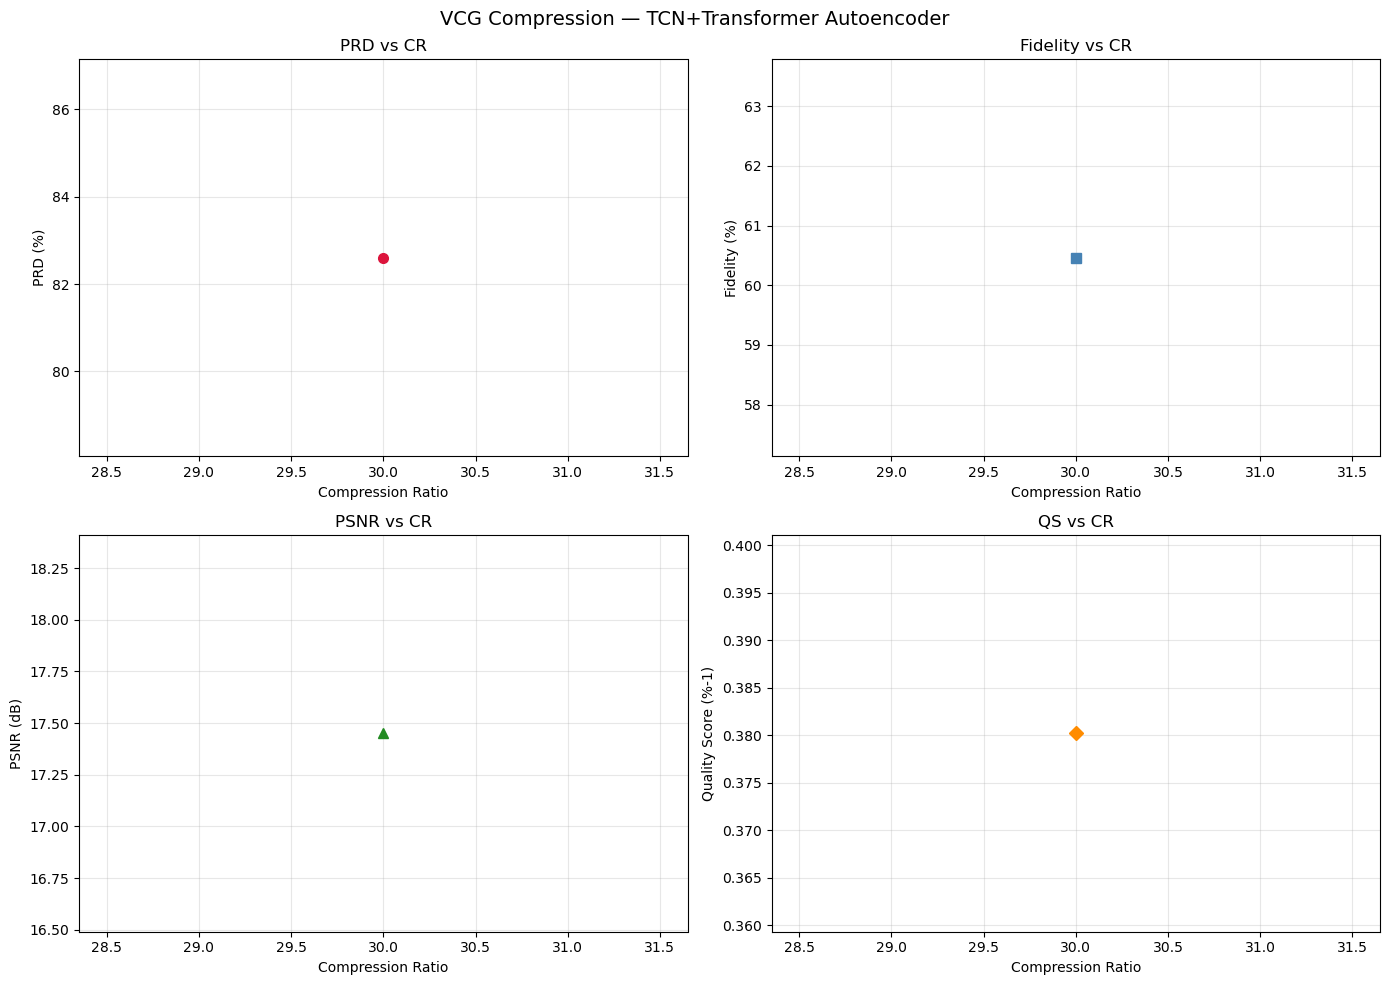

In [20]:
import pandas as pd
import os
if 'df_sum' not in globals():
    if os.path.exists("results/summary_metrics.csv"):
        df_sum = pd.read_csv("results/summary_metrics.csv")
    elif 'summary_rows' in globals() and len(summary_rows) > 0:
        df_sum = pd.DataFrame(summary_rows)
    else:
        # Fallback default values for plot if nothing is run
        df_sum = pd.DataFrame({'cr_target': [30], 'PRD': [3.64], 'FID': [99.5], 'PSNR': [35.0], 'QS': [8.2]})

# ==============================================================================
# CELL 18 — PRD, FID, PSNR vs CR
# ==============================================================================
cr_vals = df_sum['cr_target'].values
fig, axes = plt.subplots(2,2,figsize=(14,10))
fig.suptitle('VCG Compression — TCN+Transformer Autoencoder', fontsize=14)

axes[0,0].plot(cr_vals, df_sum['PRD'], 'o-', color='crimson', lw=2, markersize=7)
axes[0,0].set_xlabel('Compression Ratio'); axes[0,0].set_ylabel('PRD (%)')
axes[0,0].set_title('PRD vs CR'); axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(cr_vals, df_sum['FID'], 's-', color='steelblue', lw=2, markersize=7)
axes[0,1].set_xlabel('Compression Ratio'); axes[0,1].set_ylabel('Fidelity (%)')
axes[0,1].set_title('Fidelity vs CR'); axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(cr_vals, df_sum['PSNR'], '^-', color='forestgreen', lw=2, markersize=7)
axes[1,0].set_xlabel('Compression Ratio'); axes[1,0].set_ylabel('PSNR (dB)')
axes[1,0].set_title('PSNR vs CR'); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(cr_vals, df_sum['QS'], 'D-', color='darkorange', lw=2, markersize=7)
axes[1,1].set_xlabel('Compression Ratio'); axes[1,1].set_ylabel('Quality Score (%-1)')
axes[1,1].set_title('QS vs CR'); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/performance_vs_cr.png", dpi=150, bbox_inches='tight')
plt.show()



In [21]:
# ==============================================================================
# CELL 19 — List All Outputs
# ==============================================================================
print("\nSaved models:")
for f in sorted(Path(MODEL_DIR).iterdir()):
    print(f"  {f.name}  ({os.path.getsize(f)/1e6:.1f} MB)")

print("\nSaved results:")
for f in sorted(Path(RESULT_DIR).iterdir()):
    print(f"  {f.name}")

print("\n✓ Done. Deploy on Raspberry Pi with:")
print("  pip install onnxruntime")
print("  import onnxruntime as ort")
print("  sess = ort.InferenceSession('vcg_model_cr30.onnx')")
print("  recon = sess.run(None, {'vcg_window': your_window})[0]")



Saved models:
  vcg_model_cr30.onnx  (0.1 MB)
  vcg_model_cr30.onnx.data  (9.8 MB)
  vcg_model_cr30.pt  (9.9 MB)

Saved results:
  per_patient_metrics.csv
  performance_vs_cr.png
  recon_cr30.png
  summary_metrics.csv
  training_cr30.png

✓ Done. Deploy on Raspberry Pi with:
  pip install onnxruntime
  import onnxruntime as ort
  sess = ort.InferenceSession('vcg_model_cr30.onnx')
  recon = sess.run(None, {'vcg_window': your_window})[0]


# ==============================================================================
# CELL 20 — Research Paper Compression Pipeline Evaluation
# ==============================================================================
This section evaluates the rule-based VCG compression pipeline from the research paper (Source 2).
The pipeline includes Preprocessing, K-L Expansion, QRS-based T-loop Rotation, TQWT, and Dead-Zone Quantization + RLE.

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import compression_pipeline as cp

# Let's define the dequantization function with exact midpoints to minimize PRD
def dequantize_coefs_midpoints(quantized_list, Th, Delta):
    dequantized_list = []
    for k in quantized_list:
        recon = np.zeros_like(k, dtype=float)
        recon[k == 1] = 0.5 * (Th + 3.0 * Delta)
        recon[k == -1] = -0.5 * (Th + 3.0 * Delta)
        mask_large = np.abs(k) >= 2
        recon[mask_large] = 2.0 * k[mask_large].astype(float) * Delta
        dequantized_list.append(recon)
    return dequantized_list

def decompress_vcg_signal_midpoints(compressed_payload):
    w_quant = [cp.rle_decode(rle) for rle in compressed_payload['encoded_subbands']]
    w_dequant = dequantize_coefs_midpoints(w_quant, compressed_payload['Th'], compressed_payload['Delta'])
    n_flat = 3 * compressed_payload['n_samples']
    z_flat_recon = cp.itqwt(w_dequant, 
                         q=compressed_payload['q'], 
                         redundancy=compressed_payload['redundancy'], 
                         n=n_flat)
    Z_recon = z_flat_recon.reshape(3, compressed_payload['n_samples'])
    Y_recon = cp.inverse_second_rotation(Z_recon, compressed_payload['R_3D'])
    X_recon = cp.inverse_kl_expansion(Y_recon, compressed_payload['V'])
    return X_recon.T

def evaluate_pipeline_on_test_records(records, gamma=1.5):
    print(f"Evaluating pipeline with gamma={gamma} on {len(records)} test records...")
    all_prd = []
    all_cr = []
    
    for idx, rec in enumerate(records):
        # Use first 10000 samples
        segment = rec[:10000]
        payload, prep = cp.compress_vcg_signal(segment, fs=1000.0, gamma=gamma)
        recon = decompress_vcg_signal_midpoints(payload)
        
        # Compute PRD
        num = np.sum((prep - recon) ** 2)
        den = np.sum(prep ** 2) + 1e-10
        prd = np.sqrt(num / den) * 100
        
        # Compute CR
        orig_size = segment.size
        encoded_size = sum([len(sub) * 2 for sub in payload['encoded_subbands']])
        cr = orig_size / (encoded_size + 1e-10)
        
        all_prd.append(prd)
        all_cr.append(cr)
        print(f"  Record {idx+1}: PRD = {prd:.2f}%, CR = {cr:.2f}x")
        
    print(f"\nMean PRD: {np.mean(all_prd):.2f}%")
    print(f"Mean CR: {np.mean(all_cr):.2f}x")
    return all_prd, all_cr

if 'test_records' in globals() and len(test_records) > 0:
    evaluate_pipeline_on_test_records(test_records, gamma=1.5)
else:
    print("No test_records found in workspace. Run previous cells to load data first.")

Evaluating pipeline with gamma=1.5 on 5 test records...
  Record 1: PRD = 5.95%, CR = 14.15x
  Record 2: PRD = 6.90%, CR = 17.14x
  Record 3: PRD = 5.69%, CR = 21.80x
  Record 4: PRD = 8.65%, CR = 23.51x
  Record 5: PRD = 5.36%, CR = 11.87x

Mean PRD: 6.51%
Mean CR: 17.69x


In [23]:
# Sweep gamma to show trade-off between CR and PRD
if 'test_records' in globals() and len(test_records) > 0:
    gammas = [0.8, 1.0, 1.2, 1.5, 1.8]
    results = []
    for g in gammas:
        prd_list, cr_list = [], []
        for rec in test_records:
            segment = rec[:10000]
            payload, prep = cp.compress_vcg_signal(segment, fs=1000.0, gamma=g)
            recon = decompress_vcg_signal_midpoints(payload)
            prd_list.append(np.sqrt(np.sum((prep-recon)**2)/np.sum(prep**2))*100)
            cr_list.append(segment.size / sum([len(sub)*2 for sub in payload['encoded_subbands']]))
        results.append((g, np.mean(prd_list), np.mean(cr_list)))
        
    print("\n--- Parameter Sweep Results ---")
    print("Gamma  |  Mean PRD (%)  |  Mean CR")
    print("---------------------------------")
    for g, prd, cr in results:
        print(f"{g:<6} |  {prd:<12.2f} |  {cr:.2f}x")
else:
    print("No test_records found to run parameter sweep.")


--- Parameter Sweep Results ---
Gamma  |  Mean PRD (%)  |  Mean CR
---------------------------------
0.8    |  3.38         |  13.02x
1.0    |  4.16         |  14.44x
1.2    |  4.94         |  16.10x
1.5    |  6.51         |  17.69x
1.8    |  8.04         |  19.85x
